In [1]:
# ======================================================================
# 1) SETUP — style, paths, helpers
# ----------------------------------------------------------------------
# • Sets random seed for reproducibility.
# • Sets pretty plotting defaults and creates output folders.
# • Provides a helper to save and also show plots inline.
# ======================================================================

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve, confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

import joblib

# Reproducibility across runs
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ----- Input / Output paths (edit if you move data) --------------------
DATA_DIR = "/Users/krispyturtle/Documents/Github/junglecart/customer-rfm-churn-analysis/data"
FIG_DIR  = "./figures";  os.makedirs(FIG_DIR, exist_ok=True)
EXP_DIR  = "./exports";  os.makedirs(EXP_DIR, exist_ok=True)
MOD_DIR  = "./models";   os.makedirs(MOD_DIR, exist_ok=True)
REP_DIR  = "./reports";  os.makedirs(REP_DIR, exist_ok=True)

# ----- Plot style for a clean, professional look -----------------------
sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

def savefig_and_show(path, **kwargs):
    """
    Save the current matplotlib figure to disk, then display it inline.

    Parameters
    ----------
    path : str
        Output path (PNG).
    kwargs : dict
        Extra keyword args passed to plt.savefig (optional).
    """
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight", **kwargs)
    print(f"📸 saved figure: {path}")
    plt.show()

In [2]:
# ======================================================================
# 2) LOAD — core tables
# ----------------------------------------------------------------------
# • Loads customers, orders, order_items, payments.
# • Sets analysis_date = last order date + 1 day (used in Recency).
# ======================================================================

customers   = pd.read_csv(f"{DATA_DIR}/customers.csv", parse_dates=["signup_date"])
orders      = pd.read_csv(f"{DATA_DIR}/orders.csv",    parse_dates=["order_date"])
order_items = pd.read_csv(f"{DATA_DIR}/order_items.csv")
payments    = pd.read_csv(f"{DATA_DIR}/payments.csv",  parse_dates=["captured_at"])

analysis_date = orders["order_date"].max() + pd.Timedelta(days=1)
print("Analysis date:", analysis_date.date())

# Quick table sizes to verify load
for name, df in [
    ("customers",customers),("orders",orders),
    ("order_items",order_items),("payments",payments)
]:
    print(f"{name:12s}", len(df))

Analysis date: 2025-10-02
customers    50000
orders       55075
order_items  98942
payments     55075


📸 saved figure: ./figures/monthly_orders.png


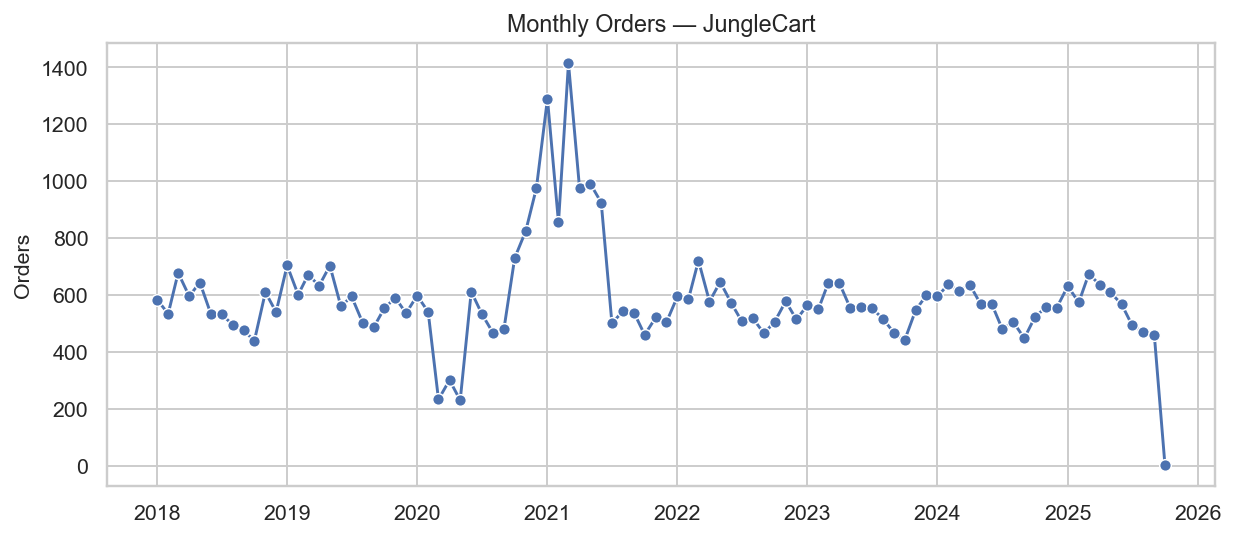

📸 saved figure: ./figures/monthly_revenue.png


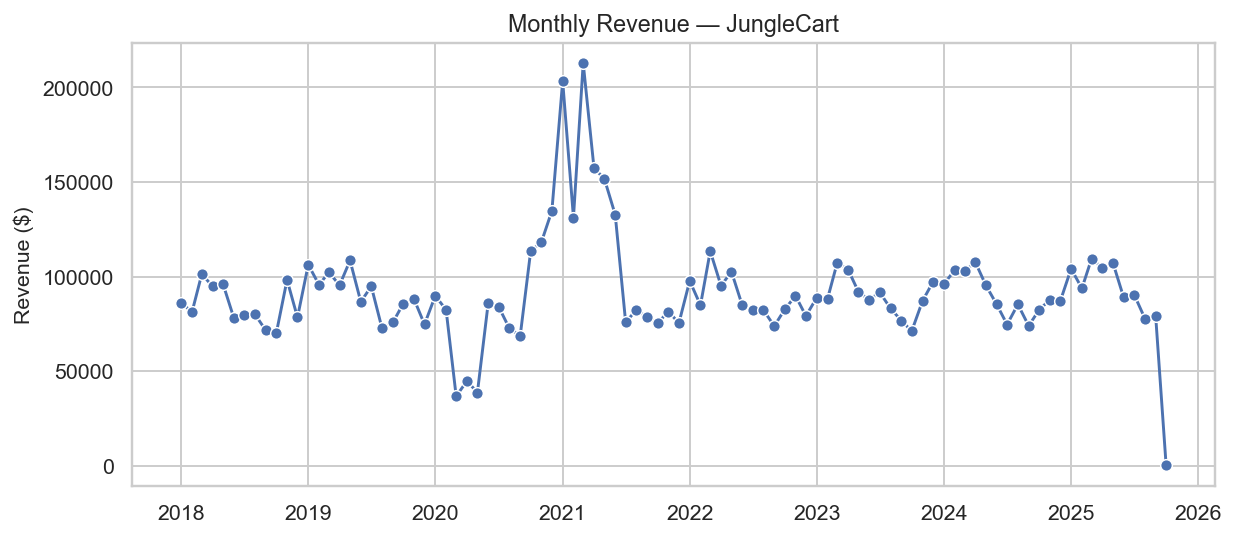

📸 saved figure: ./figures/monthly_aov_and_unique_customers.png


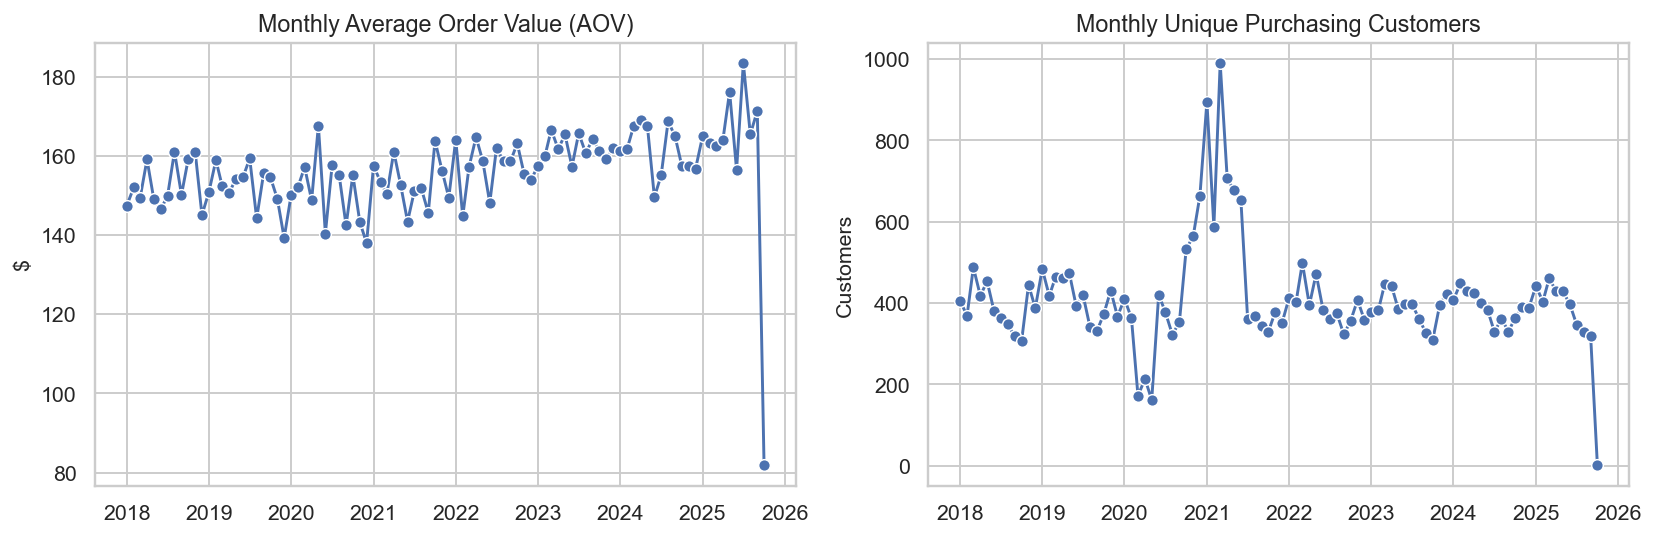

In [3]:
# ======================================================================
# 3) PREP — basic cleaning + order value + MONTHLY aggregation
# ----------------------------------------------------------------------
# • Build realized revenue per order from payments (sum of captured amounts).
# • Create monthly KPIs: orders, revenue, AOV, unique purchasing customers.
# • Plot monthly Orders, Revenue, AOV, Unique Customers (inline + PNG).
# ======================================================================

# Hygiene: ensure email column exists without NaNs (not strictly needed later)
if "email" in customers.columns:
    customers["email"] = customers["email"].fillna("unknown@na.com")

# Realized revenue per order (payments are the ground-truth for cash)
order_revenue = payments.groupby("order_id")["amount"].sum().reset_index()
orders = orders.merge(order_revenue, on="order_id", how="left") \
               .rename(columns={"amount":"order_value"})
orders["order_value"] = orders["order_value"].fillna(0)

# Basic sanity checks to catch schema surprises early
assert orders["order_id"].is_unique, "Duplicate order_id detected."
assert {"customer_id","order_date","order_value"}.issubset(orders.columns), \
       "orders missing expected columns"

# ----- MONTHLY aggregation ------------------------------------------------
# Using month-start timestamps (e.g., 2025-09-01) for clean grouping
orders["order_month"] = orders["order_date"].values.astype("datetime64[M]")

monthly = orders.groupby("order_month").agg(
    orders=("order_id","count"),
    revenue=("order_value","sum"),
    aov=("order_value","mean"),
    unique_customers=("customer_id","nunique")
).reset_index()

# ----- Visual: Monthly Orders -------------------------------------------
fig, ax = plt.subplots(figsize=(9,4))
sns.lineplot(data=monthly, x="order_month", y="orders", marker="o", ax=ax)
ax.set_title("Monthly Orders — JungleCart")
ax.set_xlabel("")
ax.set_ylabel("Orders")
savefig_and_show(f"{FIG_DIR}/monthly_orders.png"); plt.close()

# ----- Visual: Monthly Revenue ------------------------------------------
fig, ax = plt.subplots(figsize=(9,4))
sns.lineplot(data=monthly, x="order_month", y="revenue", marker="o", ax=ax)
ax.set_title("Monthly Revenue — JungleCart")
ax.set_xlabel("")
ax.set_ylabel("Revenue ($)")
savefig_and_show(f"{FIG_DIR}/monthly_revenue.png"); plt.close()

# ----- Visual: Monthly AOV & Unique Customers (dual panel) --------------
fig, axs = plt.subplots(1,2,figsize=(12,4))
sns.lineplot(data=monthly, x="order_month", y="aov", marker="o", ax=axs[0])
axs[0].set_title("Monthly Average Order Value (AOV)")
axs[0].set_xlabel("")
axs[0].set_ylabel("$")

sns.lineplot(data=monthly, x="order_month", y="unique_customers", marker="o", ax=axs[1])
axs[1].set_title("Monthly Unique Purchasing Customers")
axs[1].set_xlabel("")
axs[1].set_ylabel("Customers")
savefig_and_show(f"{FIG_DIR}/monthly_aov_and_unique_customers.png"); plt.close()

📸 saved figure: ./figures/rfm_distributions.png


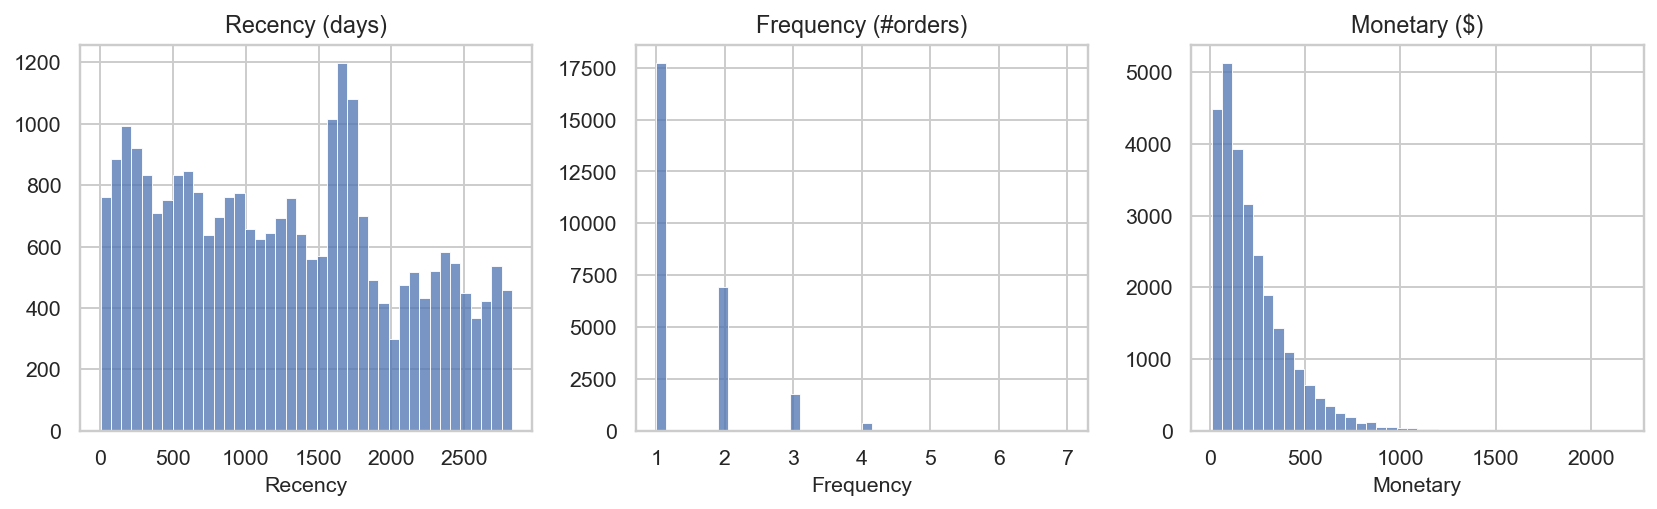

In [4]:
# ======================================================================
# 4) RFM — Recency, Frequency, Monetary (customer-level)
# ----------------------------------------------------------------------
# • Recency: days since last purchase (lower = better).
# • Frequency: number of orders in history.
# • Monetary: total realized revenue across orders.
# • Plots distributions to understand spread and skew.
# ======================================================================

rfm = orders.groupby("customer_id").agg(
    Recency   = ("order_date", lambda x: (analysis_date - x.max()).days),
    Frequency = ("order_id", "count"),
    Monetary  = ("order_value", "sum")
).reset_index()

# ----- Visual: R, F, M distributions ------------------------------------
fig, axs = plt.subplots(1,3,figsize=(12,3.8))
sns.histplot(rfm["Recency"], bins=40, ax=axs[0])
axs[0].set_title("Recency (days)"); axs[0].set_ylabel("")

sns.histplot(rfm["Frequency"], bins=40, ax=axs[1])
axs[1].set_title("Frequency (#orders)"); axs[1].set_ylabel("")

sns.histplot(rfm["Monetary"], bins=40, ax=axs[2])
axs[2].set_title("Monetary ($)"); axs[2].set_ylabel("")

savefig_and_show(f"{FIG_DIR}/rfm_distributions.png"); plt.close()

📸 saved figure: ./figures/rfm_segment_counts.png


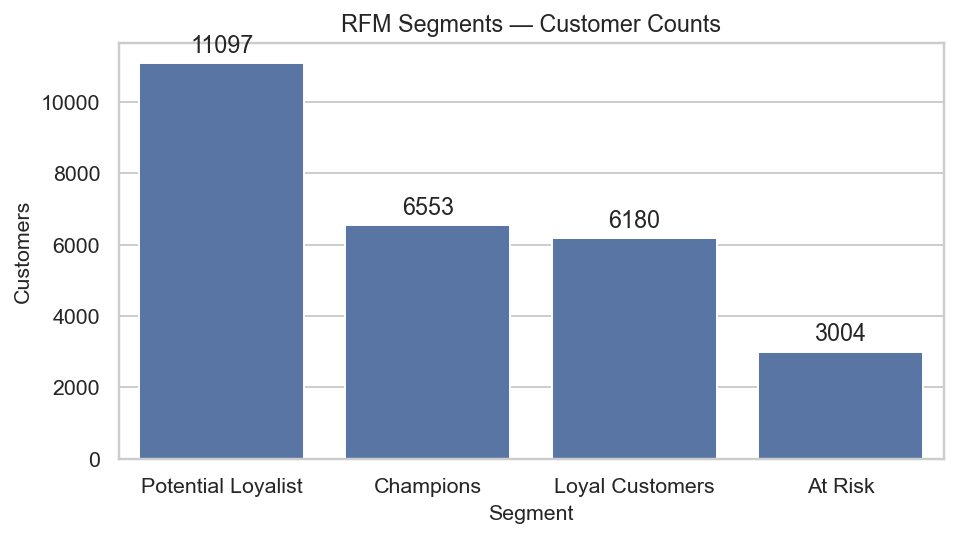

📸 saved figure: ./figures/monthly_segment_mix.png


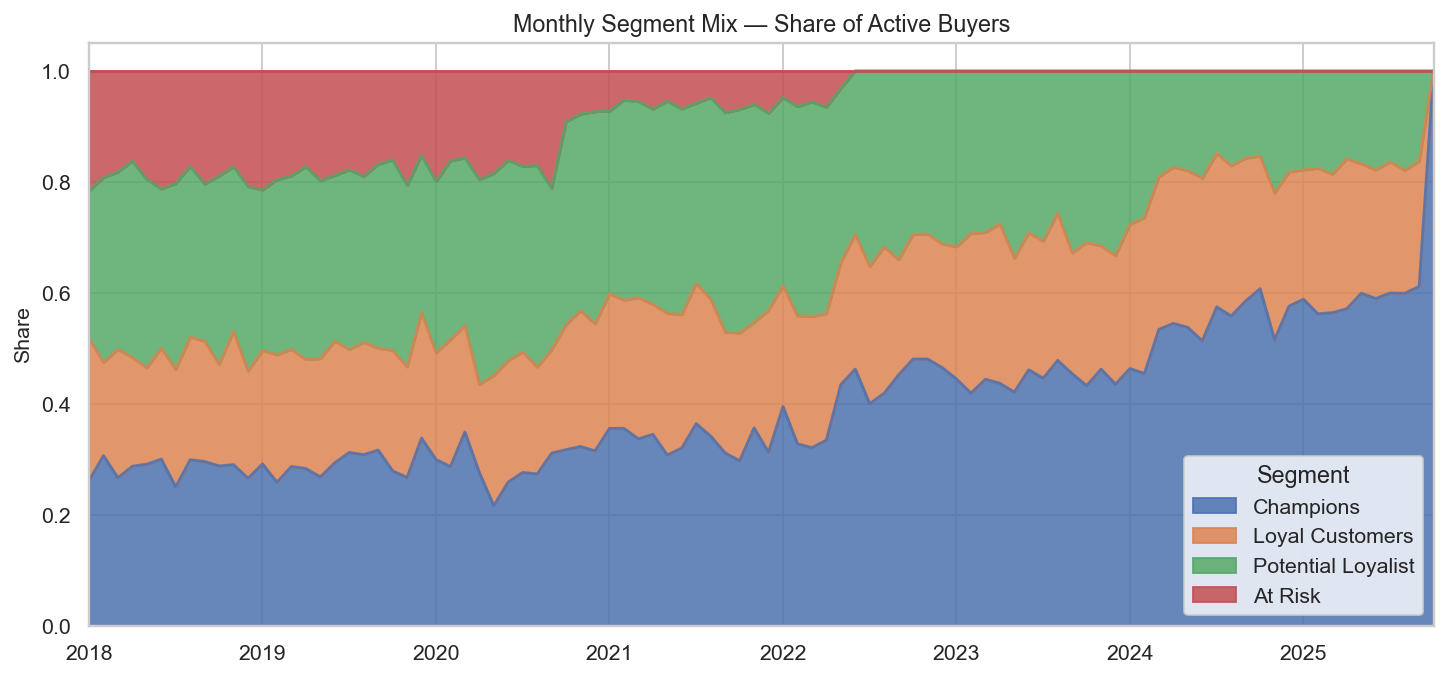

In [5]:
# ======================================================================
# 5) SEGMENTS — quantile scoring + monthly segment mix
# ----------------------------------------------------------------------
# • R_Score: lower recency → higher score (reverse labels).
# • F/M: higher values → higher score.
# • Map combined RFM_Score → business-friendly segments.
# • Plot segment size + monthly share (area chart).
# ======================================================================

# Quantile scoring; recency reversed so "4" = most recent
rfm["R_Score"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1]).astype(int)
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1,2,3,4]).astype(int)
rfm["M_Score"] = pd.qcut(rfm["Monetary"], 4, labels=[1,2,3,4]).astype(int)

rfm["RFM_Score"]   = rfm[["R_Score","F_Score","M_Score"]].sum(axis=1)
rfm["RFM_Segment"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)

def segment_map(score: int) -> str:
    """Map numeric RFM_Score → marketing-friendly segment name."""
    if score >= 10: return "Champions"
    if score >= 8:  return "Loyal Customers"
    if score >= 5:  return "Potential Loyalist"
    return "At Risk"

rfm["Segment"] = rfm["RFM_Score"].apply(segment_map)

# ----- Visual: segment counts (bar) ------------------------------------
seg_counts = rfm["Segment"].value_counts().rename_axis("Segment").reset_index(name="Customers")
order = seg_counts.sort_values("Customers", ascending=False)["Segment"]

fig, ax = plt.subplots(figsize=(7,4))
sns.barplot(data=seg_counts, x="Segment", y="Customers", order=order, ax=ax)
ax.set_title("RFM Segments — Customer Counts")
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f", padding=3)
savefig_and_show(f"{FIG_DIR}/rfm_segment_counts.png"); plt.close()

# ----- Monthly segment mix among active buyers -------------------------
# Active buyer = placed >=1 order in the month
buyers_month = orders.groupby(["order_month","customer_id"], as_index=False)["order_id"].count()
buyers_month = buyers_month.rename(columns={"order_id":"orders_in_month"})

# Attach static segment (from RFM above)
buyers_month = buyers_month.merge(rfm[["customer_id","Segment"]], on="customer_id", how="left")

# Compute share of each segment among that month’s active buyers
mix = buyers_month.groupby(["order_month","Segment"]).size().reset_index(name="customers")
tot = buyers_month.groupby("order_month").size().reset_index(name="total_customers")
mix = mix.merge(tot, on="order_month")
mix["share"] = mix["customers"] / mix["total_customers"]

# Pivot to area chart order (consistent legend)
pivot_mix = mix.pivot(index="order_month", columns="Segment", values="share").fillna(0)
pivot_mix = pivot_mix.reindex(columns=["Champions","Loyal Customers","Potential Loyalist","At Risk"], fill_value=0)

# ----- Visual: monthly segment mix (area chart) ------------------------
fig, ax = plt.subplots(figsize=(10.5,5))
pivot_mix.plot.area(ax=ax, alpha=0.85)
ax.set_title("Monthly Segment Mix — Share of Active Buyers")
ax.set_xlabel(""); ax.set_ylabel("Share")
savefig_and_show(f"{FIG_DIR}/monthly_segment_mix.png"); plt.close()

In [6]:
# ======================================================================
# 6) CHURN — definition (inactive for last 180 days) + features
# ----------------------------------------------------------------------
# • Label churn = 1 if last order is older than 180 days from analysis_date.
# • Engineer median inter-purchase gap & average order value.
# ======================================================================

# Churn threshold: 180 days of inactivity
cutoff = analysis_date - pd.Timedelta(days=180)

# Last order date per customer (merge into rfm)
last_order_per_cust = (
    orders.groupby("customer_id", as_index=False)["order_date"].max()
          .rename(columns={"order_date":"last_order_date"})
)
rfm = rfm.merge(last_order_per_cust, on="customer_id", how="left")

# Customers without orders → treat as very old → churn=1
rfm["last_order_date"] = rfm["last_order_date"].fillna(pd.Timestamp("1900-01-01"))
rfm["Churn"] = (rfm["last_order_date"] < cutoff).astype(int)

# Median inter-purchase gap in days (NaN if only 1 order)
median_gap = (
    orders.sort_values(["customer_id","order_date"])
          .groupby("customer_id")["order_date"]
          .apply(lambda x: x.diff().median().days if x.diff().notna().any() else np.nan)
)
rfm["MedianDaysBetweenOrders"] = rfm["customer_id"].map(median_gap)

# Average order value across a customer’s history
rfm["AvgOrderValue"] = rfm["customer_id"].map(
    orders.groupby("customer_id")["order_value"].mean()
).fillna(0)

print("Churn distribution (0 retained / 1 churned):")
print(rfm["Churn"].value_counts(dropna=False))

Churn distribution (0 retained / 1 churned):
Churn
1    24677
0     2157
Name: count, dtype: int64


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       647
           1       1.00      1.00      1.00      7404

    accuracy                           1.00      8051
   macro avg       1.00      1.00      1.00      8051
weighted avg       1.00      1.00      1.00      8051

ROC-AUC: 1.0
📸 saved figure: ./figures/cm_churn.png


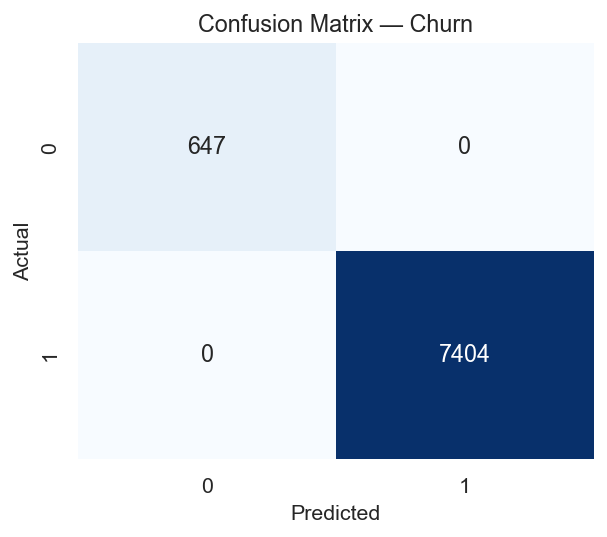

📸 saved figure: ./figures/roc_curve.png


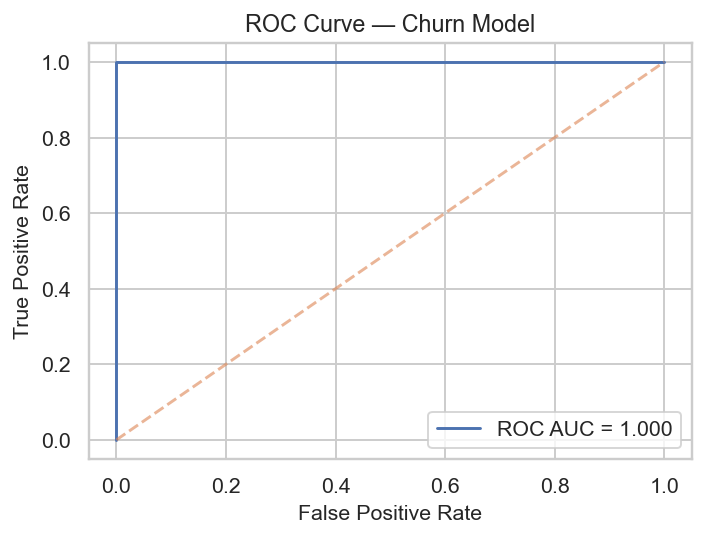

📸 saved figure: ./figures/feature_importance.png


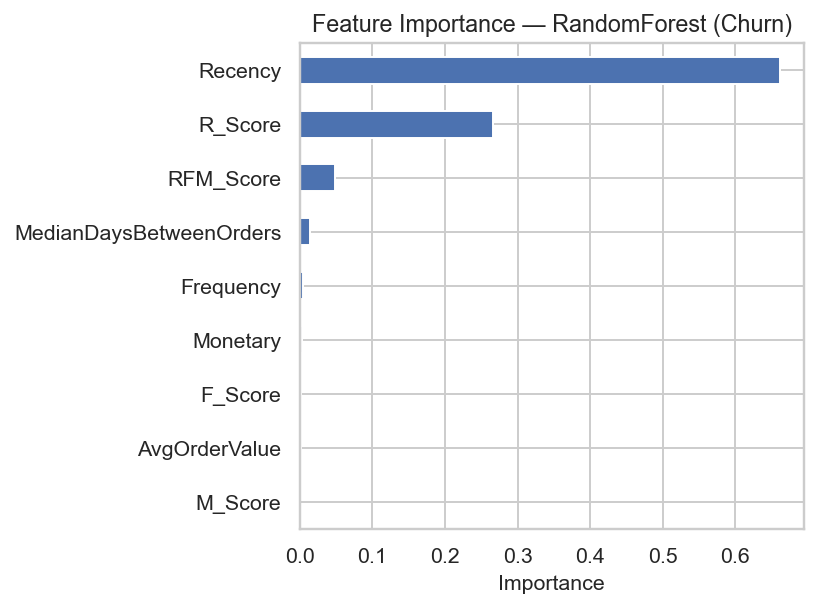

📸 saved figure: ./figures/permutation_importance.png


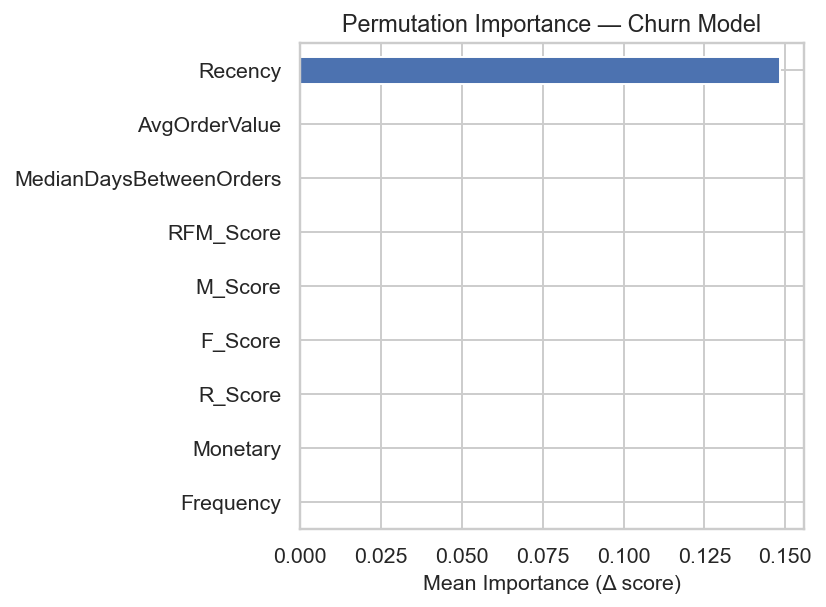

In [7]:
# ======================================================================
# 7) MODEL — RandomForest baseline + evaluation visuals
# ----------------------------------------------------------------------
# • Builds a simple, robust classifier (balanced classes via class_weight).
# • Exports: feature table, confusion matrix, ROC curve, importances.
# ======================================================================

# ----- Feature set (keep simple and stable across datasets) -------------
features = [
    "Recency","Frequency","Monetary",
    "R_Score","F_Score","M_Score","RFM_Score",
    "MedianDaysBetweenOrders","AvgOrderValue"
]

# Drop any missing labels; fill feature NaNs safely
rfm_clean = rfm.dropna(subset=["Churn"]).copy()
y = rfm_clean["Churn"].astype(int)

X = rfm_clean[features].copy()
X["MedianDaysBetweenOrders"] = X["MedianDaysBetweenOrders"].fillna(
    X["MedianDaysBetweenOrders"].median()
)
X = X.fillna(0)

# Keep a snapshot of model-ready features (useful for future experiments)
X.assign(Churn=y.values).to_csv(f"{EXP_DIR}/model_features.csv", index=False)

# Train/test split with stratification to preserve churn rate distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

# RandomForest baseline — easy, solid first pass
model = RandomForestClassifier(
    n_estimators=300, random_state=RANDOM_STATE, class_weight="balanced"
)
model.fit(X_train, y_train)

# Predictions & probabilities
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Text report for quick scanning
report_text = classification_report(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
print(report_text)
print("ROC-AUC:", round(roc_auc, 3))

# ----- Visual: Confusion matrix ---------------------------------------
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4.5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title("Confusion Matrix — Churn")
savefig_and_show(f"{FIG_DIR}/cm_churn.png"); plt.close()

# ----- Visual: ROC curve -----------------------------------------------
fpr, tpr, thr = roc_curve(y_test, y_prob)
fig, ax = plt.subplots(figsize=(5.2,4))
ax.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
ax.plot([0,1],[0,1],'--', alpha=0.6)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Churn Model"); ax.legend()
savefig_and_show(f"{FIG_DIR}/roc_curve.png"); plt.close()

# ----- Visual: Model-based feature importance --------------------------
imp = pd.Series(model.feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(6,4.5))
imp.plot(kind="barh", ax=ax)
ax.set_title("Feature Importance — RandomForest (Churn)")
ax.set_xlabel("Importance")
savefig_and_show(f"{FIG_DIR}/feature_importance.png"); plt.close()

# ----- Visual: Permutation importance (often more reliable) ------------
perm = permutation_importance(model, X_test, y_test, n_repeats=8, random_state=RANDOM_STATE)
perm_imp = pd.Series(perm.importances_mean, index=features).sort_values()

fig, ax = plt.subplots(figsize=(6,4.5))
perm_imp.plot(kind="barh", ax=ax)
ax.set_title("Permutation Importance — Churn Model")
ax.set_xlabel("Mean Importance (Δ score)")
savefig_and_show(f"{FIG_DIR}/permutation_importance.png"); plt.close()

In [8]:
# ======================================================================
# 8) EXPORTS — CSVs + model + metrics + monthly summaries
# ----------------------------------------------------------------------
# • Saves customer-level RFM (+ segments + churn).
# • Saves segment summary, monthly KPIs, monthly segment mix.
# • Saves model file and metrics for reuse.
# ======================================================================

# Enriched customer table (RFM + segment + churn)
rfm.to_csv(f"{EXP_DIR}/rfm_customers.csv", index=False)
print(f"💾 saved {EXP_DIR}/rfm_customers.csv")

# Segment summary (business-friendly rollup)
seg_summary = rfm.groupby("Segment").agg(
    customers=("customer_id","count"),
    churn_rate=("Churn","mean"),
    avg_monetary=("Monetary","mean"),
    avg_frequency=("Frequency","mean"),
    avg_recency=("Recency","mean")
).sort_values("customers", ascending=False).reset_index()
seg_summary.to_csv(f"{EXP_DIR}/segment_summary.csv", index=False)
print(f"💾 saved {EXP_DIR}/segment_summary.csv")

# Monthly KPIs and monthly segment mix
monthly.to_csv(f"{EXP_DIR}/monthly_kpis.csv", index=False)
mix.to_csv(f"{EXP_DIR}/monthly_segment_mix.csv", index=False)
print(f"💾 saved {EXP_DIR}/monthly_kpis.csv and {EXP_DIR}/monthly_segment_mix.csv")

# Persist model & metrics for later dashboards/pipelines
joblib.dump(model, f"{MOD_DIR}/rf_churn_model.joblib")
with open(f"{EXP_DIR}/classification_report.txt","w") as f:
    f.write(report_text)
with open(f"{EXP_DIR}/metrics.json","w") as f:
    json.dump({"roc_auc": float(roc_auc)}, f, indent=2)
print(f"💾 saved model + metrics to {MOD_DIR}/ and {EXP_DIR}/")

💾 saved ./exports/rfm_customers.csv
💾 saved ./exports/segment_summary.csv
💾 saved ./exports/monthly_kpis.csv and ./exports/monthly_segment_mix.csv
💾 saved model + metrics to ./models/ and ./exports/


In [9]:
# ======================================================================
# 9) SUMMARY — generate a 1-page Markdown portfolio summary
# ----------------------------------------------------------------------
# • Captures latest-month KPIs, top segments, and model metrics.
# • Ideal to paste into README or share with stakeholders.
# ======================================================================

top_segments = seg_summary.head(4)[["Segment","customers","churn_rate","avg_monetary"]]

summary_md = f"""# JungleCart — Monthly RFM & Churn (Portfolio Summary)

**Data through:** {analysis_date.date()}  
**Customers analysed:** {len(rfm):,}

## Monthly KPIs (latest)
- Orders: {int(monthly.iloc[-1]['orders'])}
- Revenue: ${monthly.iloc[-1]['revenue']:.0f}
- AOV: ${monthly.iloc[-1]['aov']:.2f}
- Unique buyers: {int(monthly.iloc[-1]['unique_customers'])}

## RFM Segments (Top by size)
{top_segments.to_markdown(index=False)}

## Churn Model
- **Model:** RandomForestClassifier (class_weight=balanced)
- **ROC-AUC:** {roc_auc:.3f}

**Top drivers (permutation importance):**
{perm_imp.sort_values(ascending=False).head(6).to_frame('importance').to_markdown()}

## Executive Notes
- Watch the **Monthly Segment Mix**—a rising **At Risk** share signals reactivation needs.
- Separate demand shifts (unique buyers) from basket shifts (AOV).
- Deploy **win-back** automations targeting high-risk high-value customers.

Artifacts saved in `figures/`, `exports/`, `models/`.
"""

with open(f"{REP_DIR}/summary.md","w") as f:
    f.write(summary_md)

print(f"📝 saved portfolio summary: {REP_DIR}/summary.md")

📝 saved portfolio summary: ./reports/summary.md
